In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import cv2

sns.set_style("whitegrid")

In [2]:
import os
import pandas as pd

DATASET_PATH = r"D:\dcgan\data\covid_xray\COVID-19_Radiography_Dataset"
CLASSES = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]
VALID_EXTENSIONS = (".png", ".jpg", ".jpeg")

data = []

for cls in CLASSES:
    class_img_dir = os.path.join(DATASET_PATH, cls, "images")

    if not os.path.isdir(class_img_dir):
        print(f"Missing folder: {class_img_dir}")
        continue

    for name in os.listdir(class_img_dir):
        full_path = os.path.join(class_img_dir, name)

        if os.path.isfile(full_path) and name.lower().endswith(VALID_EXTENSIONS):
            data.append({
                "path": full_path,
                "label": cls
            })

df = pd.DataFrame(data)

print("Total rows:", len(df))
print(df["label"].value_counts())
print(df.head())

Total rows: 21165
label
Normal             10192
Lung_Opacity        6012
COVID               3616
Viral Pneumonia     1345
Name: count, dtype: int64
                                                path  label
0  D:\dcgan\data\covid_xray\COVID-19_Radiography_...  COVID
1  D:\dcgan\data\covid_xray\COVID-19_Radiography_...  COVID
2  D:\dcgan\data\covid_xray\COVID-19_Radiography_...  COVID
3  D:\dcgan\data\covid_xray\COVID-19_Radiography_...  COVID
4  D:\dcgan\data\covid_xray\COVID-19_Radiography_...  COVID


In [3]:
bad_dirs = df[df["path"].apply(os.path.isdir)]
print("Directory paths inside df:", len(bad_dirs))

bad_non_images = df[~df["path"].str.lower().str.endswith(VALID_EXTENSIONS)]
print("Non-image paths inside df:", len(bad_non_images))

print("\nSample bad directory rows:")
print(bad_dirs.head())

Directory paths inside df: 0
Non-image paths inside df: 0

Sample bad directory rows:
Empty DataFrame
Columns: [path, label]
Index: []


In [4]:
data = []

for cls in CLASSES:
    class_path = os.path.join(DATASET_PATH, cls)
    for img_name in os.listdir(class_path):
        data.append({
            "path": os.path.join(class_path, img_name),
            "label": cls
        })

df = pd.DataFrame(data)

print("Total images:", len(df))
df.head()

Total images: 8


,path,label
0,D:\dcgan\data\covid_xray\COVID-19_Radiography_...,COVID
1,D:\dcgan\data\covid_xray\COVID-19_Radiography_...,COVID
2,D:\dcgan\data\covid_xray\COVID-19_Radiography_...,Lung_Opacity
3,D:\dcgan\data\covid_xray\COVID-19_Radiography_...,Lung_Opacity
4,D:\dcgan\data\covid_xray\COVID-19_Radiography_...,Normal


# Class Distribution

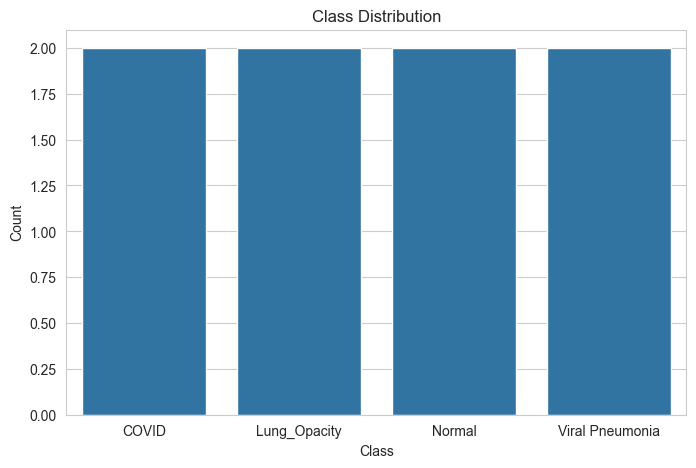

label
COVID              2
Lung_Opacity       2
Normal             2
Viral Pneumonia    2
Name: count, dtype: int64


In [5]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="label", order=CLASSES)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

print(df["label"].value_counts())

# Sample Images From Dataset

In [8]:
from PIL import Image
import matplotlib.pyplot as plt

def show_samples(df, class_name, n=5):
    class_df = df[df["label"] == class_name]
    available = len(class_df)

    if available == 0:
        print(f"No images found for class: {class_name}")
        return

    n = min(n, available)
    samples = class_df.sample(n=n, random_state=42)

    plt.figure(figsize=(3*n, 3))
    for i, (_, row) in enumerate(samples.iterrows()):
        img = Image.open(row["path"]).convert("RGB")
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


100%|██████████| 8/8 [00:00<00:00, 14116.29it/s]

Skipped: D:\dcgan\data\covid_xray\COVID-19_Radiography_Dataset\COVID\masks | [Errno 13] Permission denied: 'D:\\dcgan\\data\\covid_xray\\COVID-19_Radiography_Dataset\\COVID\\masks'
Skipped: D:\dcgan\data\covid_xray\COVID-19_Radiography_Dataset\Normal\masks | [Errno 13] Permission denied: 'D:\\dcgan\\data\\covid_xray\\COVID-19_Radiography_Dataset\\Normal\\masks'
Skipped: D:\dcgan\data\covid_xray\COVID-19_Radiography_Dataset\COVID\images | [Errno 13] Permission denied: 'D:\\dcgan\\data\\covid_xray\\COVID-19_Radiography_Dataset\\COVID\\images'
Skipped: D:\dcgan\data\covid_xray\COVID-19_Radiography_Dataset\Viral Pneumonia\masks | [Errno 13] Permission denied: 'D:\\dcgan\\data\\covid_xray\\COVID-19_Radiography_Dataset\\Viral Pneumonia\\masks'
Skipped: D:\dcgan\data\covid_xray\COVID-19_Radiography_Dataset\Lung_Opacity\images | [Errno 13] Permission denied: 'D:\\dcgan\\data\\covid_xray\\COVID-19_Radiography_Dataset\\Lung_Opacity\\images'
Skipped: D:\dcgan\data\covid_xray\COVID-19_Radiography_

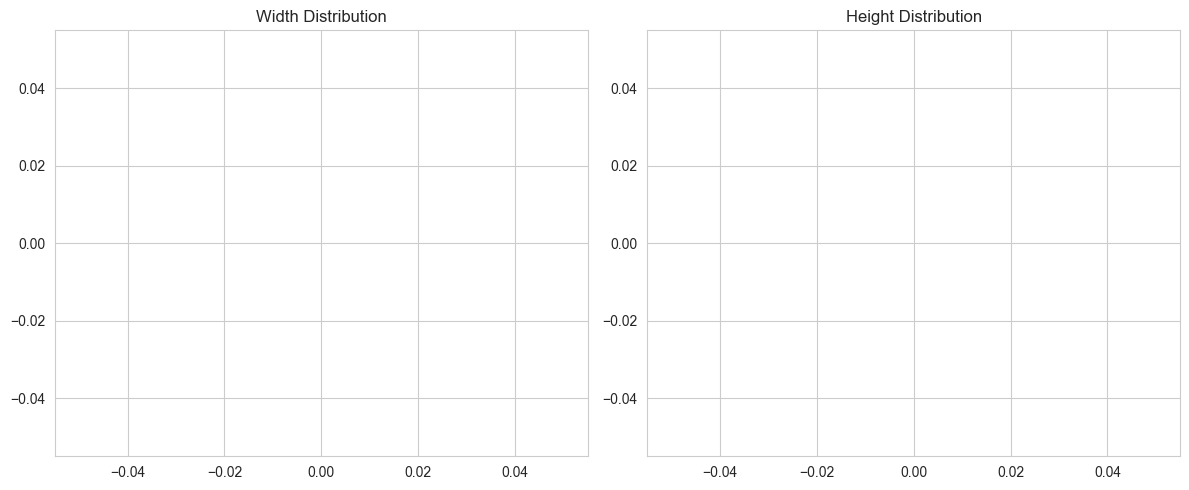

d:\dcgan\venv\lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,


Average size: nan x nan


d:\dcgan\venv\lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [9]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

widths, heights = [], []

sample_paths = df["path"].sample(min(2000, len(df)), random_state=42)

for path in tqdm(sample_paths):
    try:
        img = Image.open(path)
        w, h = img.size
        widths.append(w)
        heights.append(h)
    except Exception as e:
        print(f"Skipped: {path} | {e}")

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(widths, bins=30)
plt.title("Width Distribution")

plt.subplot(1,2,2)
sns.histplot(heights, bins=30)
plt.title("Height Distribution")

plt.tight_layout()
plt.show()

print("Average size:", np.mean(widths), "x", np.mean(heights))

In [10]:
def check_channels(path):
    img = Image.open(path)
    return len(img.getbands())

channels = [check_channels(p) for p in df["path"].sample(500)]

sns.countplot(x=channels)
plt.title("Channel Distribution")
plt.xlabel("Number of Channels")
plt.show()

print("Unique channel counts:", set(channels))

ValueError: Cannot take a larger sample than population when 'replace=False'

# Pixel Intensity Distribution

In [11]:
def get_pixel_values(paths, n=200):
    pixels = []
    for p in paths[:n]:
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        pixels.extend(img.flatten())
    return pixels

sample_paths = df["path"].sample(200).tolist()
pixels = get_pixel_values(sample_paths)

plt.figure(figsize=(8,5))
sns.histplot(pixels, bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.show()

ValueError: Cannot take a larger sample than population when 'replace=False'

# Class-wise Intensity Comparison

In [12]:
plt.figure(figsize=(10,6))

for cls in CLASSES:
    paths = df[df["label"] == cls]["path"].sample(100)
    pixels = get_pixel_values(paths.tolist(), n=100)
    sns.kdeplot(pixels, label=cls)

plt.title("Class-wise Pixel Intensity Distribution")
plt.legend()
plt.show()

ValueError: Cannot take a larger sample than population when 'replace=False'

<Figure size 1000x600 with 0 Axes>

# Edge Detection (Image Structure Insight)

TypeError: Image data of dtype object cannot be converted to float

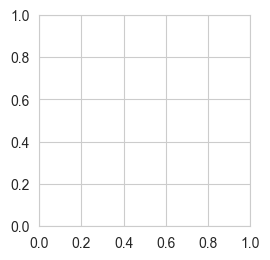

In [13]:
def show_edges(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    edges = cv2.Canny(img, 50, 150)
    
    plt.figure(figsize=(6,3))
    
    plt.subplot(1,2,1)
    plt.imshow(img, cmap="gray")
    plt.title("Original")
    plt.axis("off")
    
    plt.subplot(1,2,2)
    plt.imshow(edges, cmap="gray")
    plt.title("Edges")
    plt.axis("off")
    
    plt.show()

for cls in CLASSES:
    sample_path = df[df["label"] == cls]["path"].iloc[0]
    show_edges(sample_path)

# Duplicate / Similar Image Check

In [14]:
hashes = set()
duplicates = 0

for path in df["path"].sample(500):
    img = Image.open(path).resize((64,64))
    h = hash(img.tobytes())
    
    if h in hashes:
        duplicates += 1
    else:
        hashes.add(h)

print("Approx duplicate count (sample):", duplicates)

ValueError: Cannot take a larger sample than population when 'replace=False'